<a href="https://colab.research.google.com/github/fviniciussilva/lp/blob/main/unidade4s1LP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando experimento com 5000 registros...

=== RESULTADOS DO EXPERIMENTO ===
   Método de Inserção  Tempo Total (s) Ganho de Velocidade
 Sequencial (execute)           0.2257                  1x
Em Lote (executemany)           0.0413   5.46x mais rápido


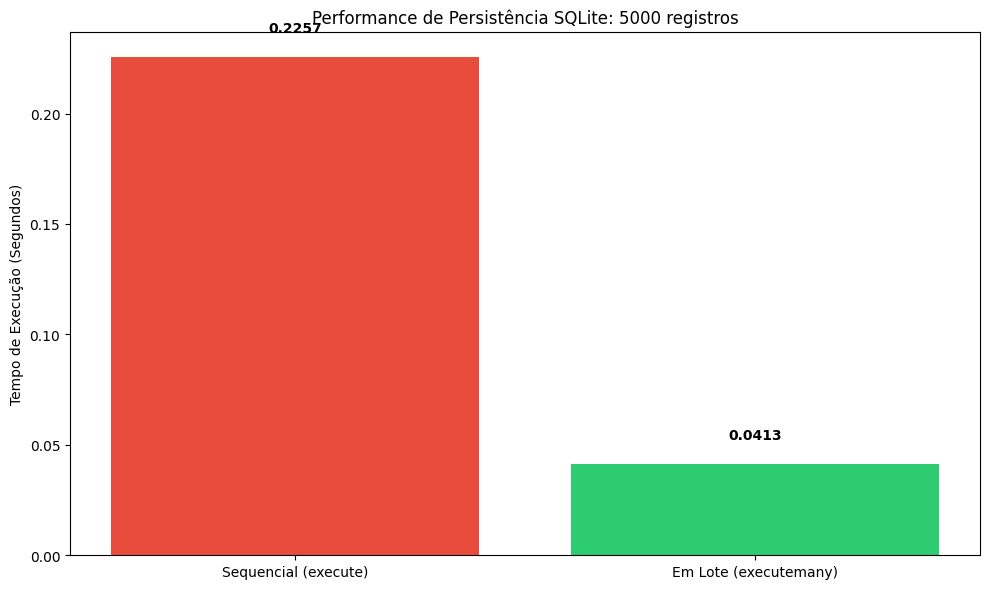


[INFO] Gráfico salvo como 'grafico.png'. Experimento concluído.


In [2]:
import sqlite3
import time
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuração de Mock Data (Simulando Web Scraping da S-Problema)
def generate_mock_data(n=10000):
    """Gera uma lista de tuplas simulando dados coletados."""
    return [
        (i, f"Manchete de Exemplo {i}", "Esportes", "2023-10-27 10:00:00")
        for i in range(n)
    ]

# 2. Funções de Persistência (Baseadas na Unidade 4)
def insert_sequential(db_conn, data):
    """Insere dados um a um (Cenário de baixa eficiência)."""
    cursor = db_conn.cursor()
    start_time = time.time()
    for row in data:
        cursor.execute("INSERT INTO noticias VALUES (?, ?, ?, ?)", row)
        db_conn.commit() # Commit individual gera alto overhead
    return time.time() - start_time

def insert_bulk(db_conn, data):
    """Insere dados em lote (Cenário de alta eficiência)."""
    cursor = db_conn.cursor()
    start_time = time.time()
    # Executemany otimiza o journaling do SQLite
    cursor.executemany("INSERT INTO noticias VALUES (?, ?, ?, ?)", data)
    db_conn.commit()
    return time.time() - start_time

# 3. Execução do Experimento
def run_experiment():
    # Setup do Banco em Memória
    conn = sqlite3.connect(":memory:")
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE noticias (id INT, manchete TEXT, secao TEXT, hora TEXT)
    """)

    n_records = 5000 # Volume para demonstração clara no Colab
    data = generate_mock_data(n_records)

    print(f"Iniciando experimento com {n_records} registros...")

    # Teste 1: Sequencial
    time_seq = insert_sequential(conn, data)
    cursor.execute("DELETE FROM noticias") # Limpa para o próximo teste

    # Teste 2: Bulk
    time_bulk = insert_bulk(conn, data)

    # 4. Processamento de Resultados
    results = {
        "Método de Inserção": ["Sequencial (execute)", "Em Lote (executemany)"],
        "Tempo Total (s)": [round(time_seq, 4), round(time_bulk, 4)]
    }

    df_results = pd.DataFrame(results)
    df_results["Ganho de Velocidade"] = [
        "1x",
        f"{round(time_seq / time_bulk, 2)}x mais rápido"
    ]

    # Exibir Tabela Final
    print("\n=== RESULTADOS DO EXPERIMENTO ===")
    print(df_results.to_string(index=False))

    # 5. Geração e Salvamento do Gráfico
    plt.figure(figsize=(10, 6))
    bars = plt.bar(df_results["Método de Inserção"], df_results["Tempo Total (s)"], color=['#e74c3c', '#2ecc71'])
    plt.ylabel('Tempo de Execução (Segundos)')
    plt.title(f'Performance de Persistência SQLite: {n_records} registros')

    # Adicionar rótulos de tempo nas barras
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, yval, ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('grafico.png') # Salva automaticamente para o artigo
    plt.show()

    print("\n[INFO] Gráfico salvo como 'grafico.png'. Experimento concluído.")

if __name__ == "__main__":
    run_experiment()